## Brownian Motion (Wiener Process)

A Brownian Motion $W_t, t \geq 0$, is a random process with the following defining properties:

1. Starts at zero: $W_0 = 0$.
2. For $0 < t_1 < t_2 < ... < t_n$, the increments $W_{t_1} - W_{t_0}, W_{t_2} - W_{t_1}, ... , W_{t_n} - W_{t_{n-1}}$ are independent.
3. Gaussian increments: $W_t - W_s \sim \mathcal{N}(0, t-s), t > s$.
4. Continuous paths: $t \rightarrow W_t$ is continuous (but nowhere differentiable almost surely).

$\textbf{Intuition}$:
Over a tiny time step $dt$, $W_t \sim \mathcal{N}(0, dt)$ has mean (or expected) change 0 with variance $dt$.

## Stochastic Differential Equation (SDE)

A typical SDE looks like $dX_t = \mu(X_t, t) dt + \sigma(X_t, t) dW_t$, \
where $X_t$ is an unknown random process, \
$\mu$ is a drift (deterministic trend), \
$\sigma$ is diffusion (noise strength), \
$W_t$ is a Brownian motion.

$\textbf{Interpretation:}$ Over a tiny time step $dt$, the difference is $X_{t+dt} - X_t \approx \mu(X_t, t) dt + \sigma(X_t, t) \sqrt{dt} Z$, where $Z \sim \mathcal{N}(0,1)$. \
So drift contributes with an order of $dt$ and randomness with an order of $\sqrt{dt}$. As such, the $\sqrt{dt}$ dominates tiny fluctuations.

## Example: Arithmetic Brownian Motion

$dX_t = \mu dt + \sigma W_t$ \
Solution: $X_t = X_0 + \mu t + \sigma W_t$ \
with mean $\mathbb{E}[X_t] = X_0 + \mu t$ and variance $Var(X_t) = \sigma^2 t$.

## Example: Geometric Brownian Motion

Used in finance for stock prices: $dS_t = \mu S_t dt +  \sigma S_t dW_t$. \
Solution: $S_t = S_0 \exp\left[\left( \mu - \frac{1}{2} \sigma^2 \right) t + \sigma W_t \right]$. \
This keeps $S_t > 0$.

## Itô's Key Rule

Because $dW_t$ is rough, multiplication rules differ from normal calculus: \
$dW_t^2 = dt$ \
$dW_t dt = 0$ \
$dt^2 = 0$

This leads to Itô's Lemma (the stochastic chain rule): \
If $f(t, X_t)$ then \
$df = (f_t + \mu f_x + \frac{1}{2} \sigma^2 f_{xx}) dt + \sigma f_x dW_t$ \
for $dX_t = \mu dt + \sigma W_t$.

## Example simulation of Arithmetic Brownian Motion

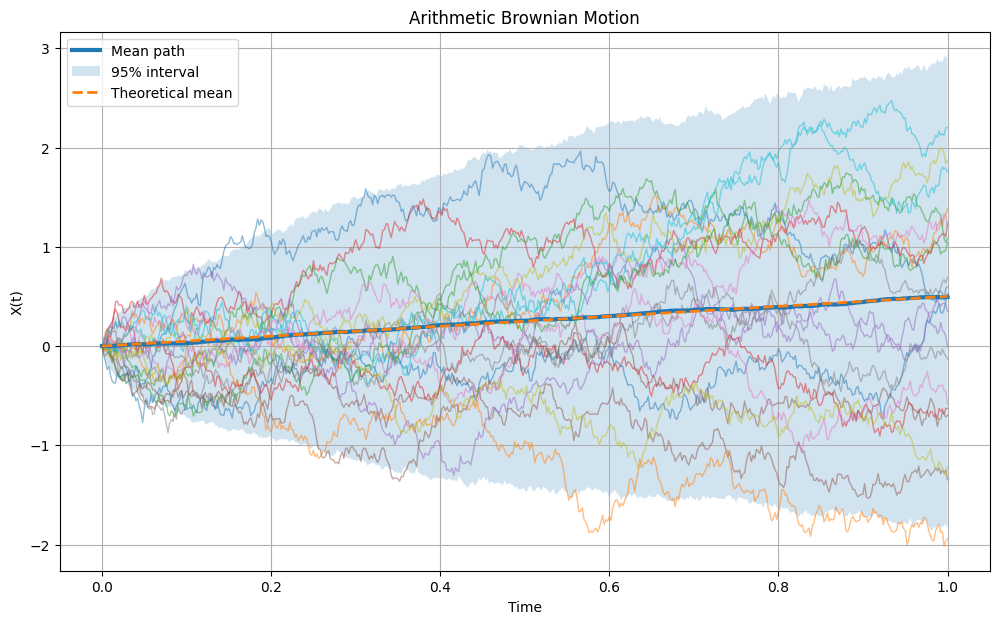

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1.0          # total time
N = 500          # time steps
M = 1000         # number of simulated paths
dt = T / N

mu = 0.5
sigma = 1.2
X0 = 0.0

# Time grid
t = np.linspace(0, T, N + 1)

# Brownian increments
dW = np.sqrt(dt) * np.random.randn(M, N)

# Brownian paths
W = np.cumsum(dW, axis=1)
W = np.column_stack([np.zeros(M), W])

# Arithmetic Brownian Motion
X = X0 + mu * t + sigma * W

# Statistics across paths
mean_path = X.mean(axis=0)
lower = np.percentile(X, 2.5, axis=0)
upper = np.percentile(X, 97.5, axis=0)

# Plot
plt.figure(figsize=(12,7))

# Sample paths
for i in range(20):
    plt.plot(t, X[i], alpha=0.5, lw=1)

# Mean path
plt.plot(t, mean_path, lw=3, label='Mean path')

# Confidence interval
plt.fill_between(t, lower, upper, alpha=0.2, label='95% interval')

# Theoretical mean
plt.plot(t, X0 + mu*t, '--', lw=2, label='Theoretical mean')

plt.title("Arithmetic Brownian Motion")
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.legend()
plt.grid(True)
plt.show()

## Example simulation of Geometric Brownian Motion

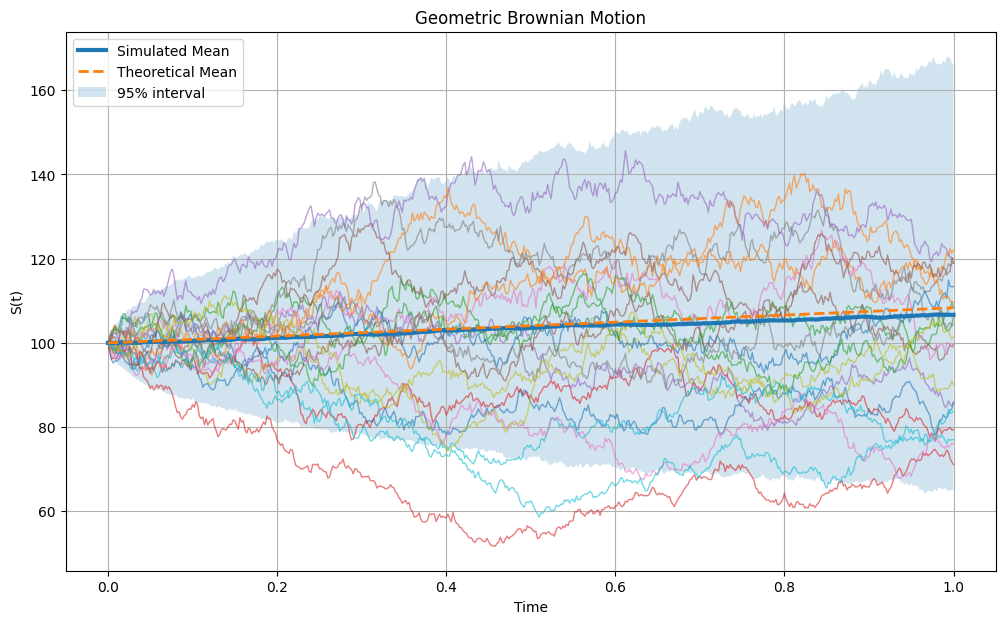

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1.0
N = 500
M = 1000
dt = T / N

S0 = 100
mu = 0.08
sigma = 0.25

# Time grid
t = np.linspace(0, T, N + 1)

# Brownian increments
dW = np.sqrt(dt) * np.random.randn(M, N)

# Brownian paths
W = np.cumsum(dW, axis=1)
W = np.column_stack([np.zeros(M), W])

# Exact GBM solution
S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# Monte Carlo stats
mean_path = S.mean(axis=0)
lower = np.percentile(S, 2.5, axis=0)
upper = np.percentile(S, 97.5, axis=0)

# Theoretical expectation
theoretical_mean = S0 * np.exp(mu * t)

# Plot
plt.figure(figsize=(12,7))

# Sample paths
for i in range(20):
    plt.plot(t, S[i], alpha=0.6, lw=1)

# Mean path
plt.plot(t, mean_path, lw=3, label="Simulated Mean")

# Theory mean
plt.plot(t, theoretical_mean, '--', lw=2, label="Theoretical Mean")

# Confidence band
plt.fill_between(t, lower, upper, alpha=0.2, label="95% interval")

plt.title("Geometric Brownian Motion")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.legend()
plt.grid(True)
plt.show()

# Determining $\mu$ and $\sigma$ in a Stochastic Differential Equation

Consider the stochastic process:

$$
dX_t = \mu(X_t,t)\,dt + \sigma(X_t,t)\,dW_t
$$

To use this as a model, we need to determine:

- $\mu$ = drift term (systematic trend)
- $\sigma$ = diffusion term (random variability / noise level)

These are usually **not known in advance**. They are typically chosen from:

1. Data estimation  
2. Theory / domain knowledge  
3. Calibration to observed prices or outcomes  
4. Model assumptions

---

# 1. What $\mu$ and $\sigma$ Mean

## Drift $\mu$

The drift controls the expected instantaneous change:

$$
\mathbb{E}[dX_t] = \mu\,dt
$$

So $\mu$ represents the average direction or growth rate.

Examples:

- stock with upward trend  
- population growth  
- temperature tendency  
- physical velocity trend

---

## Volatility $\sigma$

The diffusion controls randomness:

$$
\operatorname{Var}(dX_t) = \sigma^2 dt
$$

So $\sigma$ measures uncertainty / noise intensity.

Large $\sigma$ = noisy process  
Small $\sigma$ = stable process

---

# 2. Do They Come From Data?

## Yes — Often Estimated from Historical Data

Suppose we observe:

$$
X_{t_0}, X_{t_1}, X_{t_2}, \dots
$$

Then increments are:

$$
\Delta X_i = X_{t_{i+1}} - X_{t_i}
$$

For arithmetic Brownian motion:

$$
dX_t = \mu dt + \sigma dW_t
$$

we know:

$$
\Delta X_i \sim N(\mu \Delta t,\sigma^2 \Delta t)
$$

So estimate:

$$
\hat{\mu} = \frac{\operatorname{mean}(\Delta X)}{\Delta t}
$$

$$
\hat{\sigma} = \frac{\operatorname{std}(\Delta X)}{\sqrt{\Delta t}}
$$

This is basic statistical estimation.

---

# 3. For Geometric Brownian Motion

Model:

$$
dS_t = \mu S_t dt + \sigma S_t dW_t
$$

Use **log returns**:

$$
r_i = \log\left(\frac{S_{i+1}}{S_i}\right)
$$

Then:

$$
r_i \approx \left(\mu - \frac12\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z
$$

So estimate $\mu$ and $\sigma$ from return data.

This is standard in finance.

---

# 4. Can $\mu$ and $\sigma$ Depend on Time or State?

Yes.

General model:

$$
dX_t = \mu(X_t,t)dt + \sigma(X_t,t)dW_t
$$

Examples:

## Mean Reversion

$$
dX_t = \kappa(\theta - X_t)dt + \sigma dW_t
$$

Here the drift depends on the current state.

## Volatility Depends on Level

$$
\sigma(X_t)=0.2X_t
$$

Used in multiplicative processes.

---

# 5. Sometimes They Come From Physics or Theory

Instead of estimating freely, equations may imply them.

Example:

## Particle with Friction

$$
dV_t = -\gamma V_t dt + \sigma dW_t
$$

where:

- $\gamma$ comes from drag laws  
- $\sigma$ comes from thermal noise

So parameters come from physical principles.

---

# 6. Sometimes They Are Calibrated

Especially in finance.

Choose $\mu$ and $\sigma$ so the model reproduces:

- option prices  
- market volatility surface  
- bond yields  
- observed distributions

This is called **calibration**.

---

# 7. Important Practical Note

Estimating $\mu$ is usually much harder than estimating $\sigma$.

Why?

Because drift accumulates slowly:

$$
\mu dt
$$

while noise fluctuates as:

$$
\sigma \sqrt{dt}
$$

Over short horizons, randomness dominates.

So in many real datasets:

- $\sigma$ can be estimated fairly well  
- $\mu$ is noisy and uncertain

---

# 8. Summary

$\mu$ and $\sigma$ are not magical constants.

They usually come from:

- historical data  
- theory  
- calibration  
- scientific assumptions

They may be constants or functions of state/time.

---

# 9. Intuition

If you observe many trajectories:

- $\mu$ = average direction of motion  
- $\sigma$ = amount of wobble around that direction

---

# 10. Next Natural Question

How do we estimate $\mu$ and $\sigma$ rigorously using **Maximum Likelihood Estimation** from data?

That is the standard statistical route into SDE parameter estimation.

# Estimating $\mu$ and $\sigma$ from an Example Dataset

We assume the process follows **Arithmetic Brownian Motion**:

$$
dX_t = \mu dt + \sigma dW_t
$$

This means over discrete time steps $\Delta t$:

$$
\Delta X_i = X_{t_{i+1}} - X_{t_i} \sim N(\mu \Delta t,\sigma^2 \Delta t)
$$

So if we observe data, we can estimate $\mu$ and $\sigma$ from the increments.

---

# 1. Example Dataset

Suppose we observe the process daily:

| Day | $X_t$ |
|----|------|
| 0 | 10.0 |
| 1 | 10.4 |
| 2 | 10.1 |
| 3 | 10.8 |
| 4 | 11.0 |
| 5 | 10.6 |

Assume:

$$
\Delta t = 1
$$

(day units)

---

# 2. Compute Increments

$$
\Delta X_i = X_{i+1} - X_i
$$

So:

| Interval | Increment |
|--------|----------|
| 0→1 | 0.4 |
| 1→2 | -0.3 |
| 2→3 | 0.7 |
| 3→4 | 0.2 |
| 4→5 | -0.4 |

So:

$$
\Delta X = [0.4,-0.3,0.7,0.2,-0.4]
$$

---

# 3. Estimate $\mu$

Use:

$$
\hat{\mu} = \frac{\text{mean}(\Delta X)}{\Delta t}
$$

Mean increment:

$$
\frac{0.4 + (-0.3) + 0.7 + 0.2 + (-0.4)}{5}
=
\frac{0.6}{5}
=
0.12
$$

Therefore:

$$
\boxed{\hat{\mu}=0.12}
$$

Interpretation:

Average upward drift is 0.12 units per day.

---

# 4. Estimate $\sigma$

Use sample standard deviation of increments:

$$
\hat{\sigma} = \frac{\operatorname{std}(\Delta X)}{\sqrt{\Delta t}}
$$

Since $\Delta t=1$, this is just the standard deviation.

Compute deviations from mean:

$$
[0.28,\,-0.42,\,+0.58,\,+0.08,\,-0.52]
$$

Squares:

$$
[0.0784,0.1764,0.3364,0.0064,0.2704]
$$

Sum:

$$
0.868
$$

Sample variance:

$$
s^2 = \frac{0.868}{4}=0.217
$$

Standard deviation:

$$
\sqrt{0.217}=0.466
$$

Therefore:

$$
\boxed{\hat{\sigma}=0.466}
$$

---

# 5. Final Estimated Model

So the fitted SDE becomes:

$$
dX_t = 0.12\,dt + 0.466\,dW_t
$$

---

# 6. Interpretation

- Drift $\hat{\mu}=0.12$ means upward tendency.
- Volatility $\hat{\sigma}=0.466$ means typical random movement size.

In one day:

$$
\Delta X \sim N(0.12,\,0.466^2)
$$

---

# 7. Python Version

In [30]:
import numpy as np

X = np.array([10.0, 10.4, 10.1, 10.8, 11.0, 10.6])

dX = np.diff(X)
dt = 1.0

mu_hat = np.mean(dX) / dt
sigma_hat = np.std(dX, ddof=1) / np.sqrt(dt)

print("mu_hat =", mu_hat)
print("sigma_hat =", sigma_hat)

mu_hat = 0.11999999999999993
sigma_hat = 0.4658325879540853


# Simulating Arithmetic Brownian Motion Using Estimated $\mu$ and $\sigma$

From the previous dataset, we estimated:

$$
\hat{\mu}=0.12,\qquad \hat{\sigma}=0.466
$$

So our fitted model is:

$$
dX_t = 0.12\,dt + 0.466\,dW_t
$$

We now simulate future sample paths from this estimated process.

---

# 1. Idea

For small time step $\Delta t$:

$$
X_{t+\Delta t} = X_t + \mu \Delta t + \sigma \sqrt{\Delta t}\,Z_t
$$

where:

$$
Z_t \sim N(0,1)
$$

independently each step.

This is the **Euler simulation scheme**.

# 2. Python Code

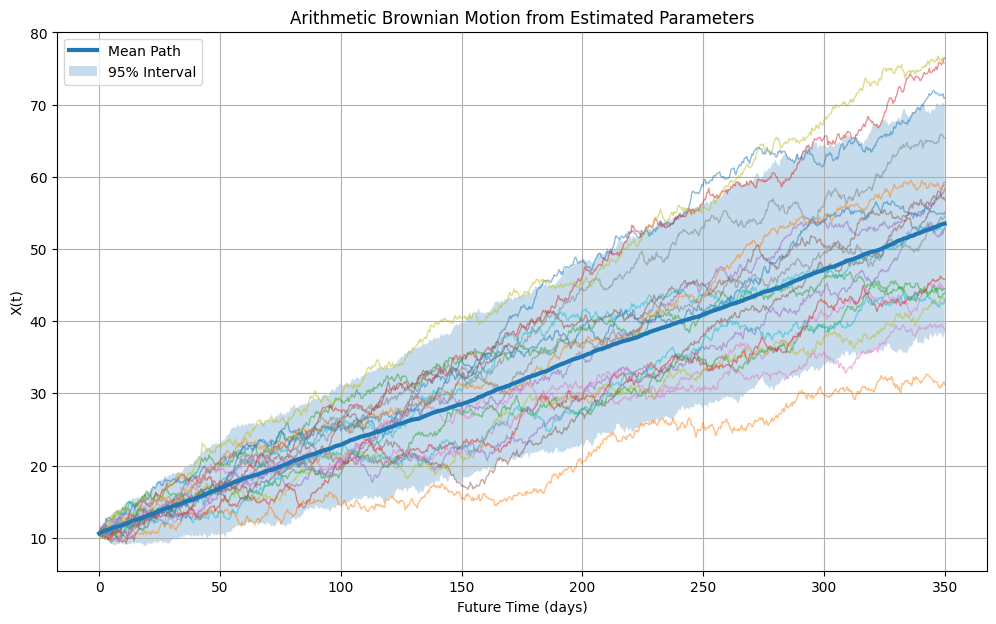

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Estimated parameters
mu = 0.12
sigma = 0.466

# Simulation settings
X0 = 10.6          # last observed value
T = 350            # simulate 200 future days
N = 1000           # steps
M = 200            # number of paths

dt = T / N
t = np.linspace(0, T, N + 1)

# Simulate paths
X = np.zeros((M, N + 1))
X[:, 0] = X0

for i in range(N):
    Z = np.random.randn(M)
    X[:, i+1] = X[:, i] + mu*dt + sigma*np.sqrt(dt)*Z

# Statistics
mean_path = X.mean(axis=0)
lower = np.percentile(X, 2.5, axis=0)
upper = np.percentile(X, 97.5, axis=0)

# Plot
plt.figure(figsize=(12,7))

for j in range(20):
    plt.plot(t, X[j], alpha=0.5, lw=1)

plt.plot(t, mean_path, lw=3, label="Mean Path")
plt.fill_between(t, lower, upper, alpha=0.25, label="95% Interval")

plt.title("Arithmetic Brownian Motion from Estimated Parameters")
plt.xlabel("Future Time (days)")
plt.ylabel("X(t)")
plt.legend()
plt.grid(True)
plt.show()

# Estimating $\mu$ and $\sigma$ Assuming Geometric Brownian Motion

Now we use the same dataset, but assume the process follows **Geometric Brownian Motion (GBM)** instead of Arithmetic Brownian Motion.

This is the classic stock-price model:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t
$$

where:

- $\mu$ = expected proportional growth rate  
- $\sigma$ = volatility  
- $S_t > 0$ is the price/process level

---

# 1. Our Same Dataset

| Day | $S_t$ |
|----|------|
| 0 | 10.0 |
| 1 | 10.4 |
| 2 | 10.1 |
| 3 | 10.8 |
| 4 | 11.0 |
| 5 | 10.6 |

Assume:

$$
\Delta t = 1
$$

(day units)

---

# 2. Why We Use Log Returns

For GBM, we work with:

$$
r_i = \log\left(\frac{S_{i+1}}{S_i}\right)
$$

because GBM implies log returns are approximately normal.

---

# 3. Compute Log Returns

## Day 0 → 1

$$
\log(10.4/10.0)=0.03922
$$

## Day 1 → 2

$$
\log(10.1/10.4)=-0.02927
$$

## Day 2 → 3

$$
\log(10.8/10.1)=0.06699
$$

## Day 3 → 4

$$
\log(11.0/10.8)=0.01835
$$

## Day 4 → 5

$$
\log(10.6/11.0)=-0.03704
$$

So:

$$
r = [0.03922,\,-0.02927,\,0.06699,\,0.01835,\,-0.03704]
$$

---

# 4. Mean and Standard Deviation of Returns

Average:

$$
\bar r = 0.01165
$$

Sample standard deviation:

$$
s = 0.04396
$$

---

# 5. Relationship Under GBM

For one-step returns:

$$
r_i \sim N\left(\left(\mu-\frac12\sigma^2\right)\Delta t,\sigma^2\Delta t\right)
$$

Since $\Delta t = 1$:

$$
\sigma = s
$$

So:

$$
\boxed{\hat{\sigma}=0.04396}
$$

Then:

$$
\mu = \bar r + \frac12\sigma^2
$$

Compute:

$$
\mu = 0.01165 + \frac12(0.04396^2)
$$

$$
\mu = 0.01165 + 0.00097
$$

$$
\boxed{\hat{\mu}=0.01262}
$$

---

# 6. Final Estimated GBM Model

So the fitted stochastic process is:

$$
dS_t = 0.01262\,S_t\,dt + 0.04396\,S_t\,dW_t
$$

---

# 7. Interpretation

## Drift

$$
\mu = 0.01262
$$

About **1.26% expected growth per day** in this tiny dataset.

## Volatility

$$
\sigma = 0.04396
$$

About **4.40% daily volatility**.

---

# 8. Why These Numbers Differ from Arithmetic Brownian Motion

Arithmetic Brownian Motion models **absolute changes**:

$$
\Delta X
$$

GBM models **percentage changes**:

$$
\Delta S / S
$$

So:

- arithmetic model: units of price  
- GBM model: proportional returns

That is why finance usually prefers GBM.

---

# 9. Python Version

In [43]:
import numpy as np

S = np.array([10.0, 10.4, 10.1, 10.8, 11.0, 10.6])

r = np.log(S[1:] / S[:-1])

r_bar = np.mean(r)
sigma_hat = np.std(r, ddof=1)
mu_hat = r_bar + 0.5 * sigma_hat**2

print("mu_hat =", mu_hat)
print("sigma_hat =", sigma_hat)

mu_hat = 0.012643175184750576
sigma_hat = 0.044483560108324494


# Simulating the Estimated Geometric Brownian Motion Model

From the previous estimation, we obtained:

$$
\hat{\mu}=0.01262,\qquad \hat{\sigma}=0.04396
$$

So our fitted model is:

$$
dS_t = 0.01262\,S_t\,dt + 0.04396\,S_t\,dW_t
$$

We now simulate future sample paths.

---

# 1. Starting Value

Use the final observed data point as today’s value:

$$
S_0 = 10.6
$$

---

# 2. Exact GBM Simulation Formula

For time grid $t_0,t_1,\dots,t_N$:

$$
S_{t+\Delta t}
=
S_t
\exp\left[
\left(\mu-\frac12\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}\,Z_t
\right]
$$

where:

$$
Z_t \sim N(0,1)
$$

independently each step.

This preserves positivity.


# 3. Python Code

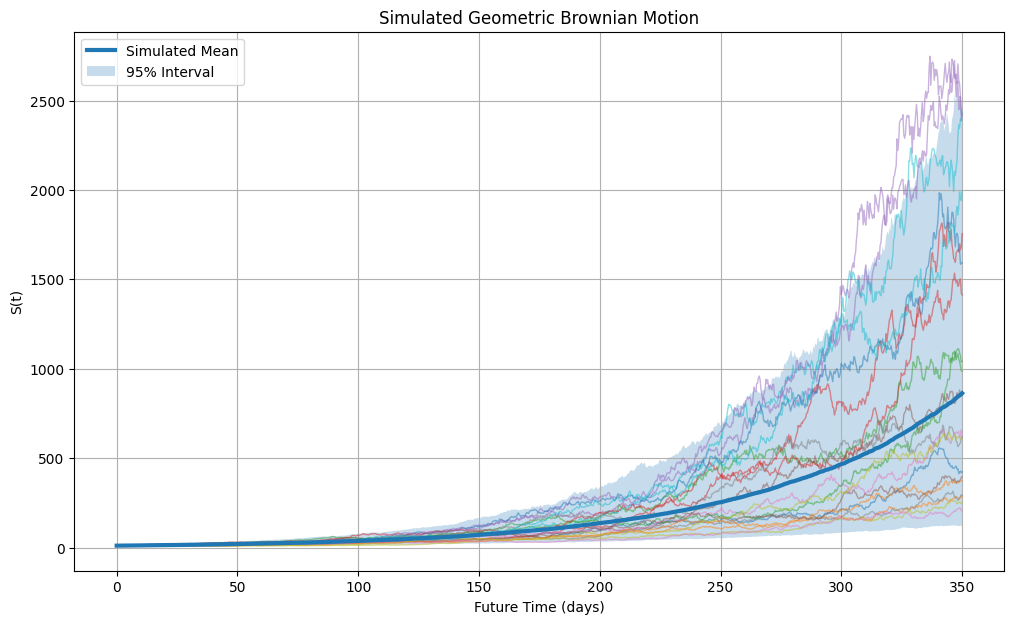

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Estimated parameters
mu = 0.01262
sigma = 0.04396

# Initial value
S0 = 10.6

# Simulation settings
T = 350         # future days
N = 1000        # time steps
M = 500         # number of paths

dt = T / N
t = np.linspace(0, T, N + 1)

# Allocate array
S = np.zeros((M, N + 1))
S[:, 0] = S0

# Simulate GBM paths
for i in range(N):
    Z = np.random.randn(M)
    S[:, i+1] = S[:, i] * np.exp(
        (mu - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z
    )

# Statistics
mean_path = S.mean(axis=0)
lower = np.percentile(S, 2.5, axis=0)
upper = np.percentile(S, 97.5, axis=0)


# Plot
plt.figure(figsize=(12,7))

for j in range(20):
    plt.plot(t, S[j], alpha=0.5, lw=1)

plt.plot(t, mean_path, lw=3, label="Simulated Mean")
plt.fill_between(t, lower, upper, alpha=0.25, label="95% Interval")

plt.title("Simulated Geometric Brownian Motion")
plt.xlabel("Future Time (days)")
plt.ylabel("S(t)")
plt.legend()
plt.grid(True)
plt.show()

# Why does $(dW_t)^2 = dt$?

This is one of the most important ideas in Itô calculus. It is **not standard algebra**, but a rule that comes from how Brownian motion scales in small time intervals.

---

# 1. Start from Brownian motion increments

For Brownian motion $W_t$, define:

$$
dW_t = W_{t+dt} - W_t
$$

We know:

$$
dW_t \sim \mathcal{N}(0, dt)
$$

So:

- Mean:
$$
\mathbb{E}[dW_t] = 0
$$

- Variance:
$$
\mathbb{E}[(dW_t)^2] = dt
$$

---

# 2. Key scaling insight

A Gaussian random variable with variance $dt$ has size:

$$
dW_t = O(\sqrt{dt})
$$

So:

- $dW_t \sim \sqrt{dt}$
- $(dW_t)^2 \sim dt$

This is the crucial scaling difference.

---

# 3. The Itô calculus “bookkeeping rules”

When expanding stochastic differentials, we treat orders of smallness as:

- $dt \sim O(dt)$
- $dW_t \sim O(\sqrt{dt})$
- $(dW_t)^2 \sim O(dt)$
- $dt \cdot dW_t \sim O(dt^{3/2}) \to 0$
- $(dt)^2 \sim O(dt^2) \to 0$

So we keep:

$$
(dW_t)^2 = dt
$$

and drop higher-order terms.

---

# 4. Why this is not ordinary algebra

In standard calculus:

- infinitesimals are deterministic
- $(dx)^2 \to 0$

But here:

- $dW_t$ is random
- its variance is **order $dt$**

So squaring it does **not vanish**.

---

# 5. Discrete intuition (important)

Approximate Brownian motion by:

$$
\Delta W = \sqrt{dt}\,Z,\quad Z \sim \mathcal{N}(0,1)
$$

Then:

$$
(\Delta W)^2 = dt \cdot Z^2
$$

Taking expectation:

$$
\mathbb{E}[(\Delta W)^2] = dt
$$

So in the limit:

$$
(dW_t)^2 \approx dt
$$

---

# 6. Why this matters (core consequence)

This rule is exactly why stochastic calculus differs from classical calculus.

Example: if

$$
X_t = W_t^2
$$

Then Itô's lemma gives:

$$
d(W_t^2) = 2W_t\,dW_t + dt
$$

That extra $dt$ term comes directly from:

$$
(dW_t)^2 = dt
$$

---

# 7. Connection to GBM

For geometric Brownian motion:

$$
dS_t = \mu S_t dt + \sigma S_t dW_t
$$

When applying Itô's lemma to $\log S_t$, the term:

$$
-\frac{1}{2}\sigma^2
$$

appears **exactly because**

$$
(dW_t)^2 = dt
$$

---

# 8. Intuition summary

- $dW_t$ behaves like $\sqrt{dt}$
- squaring it produces something of order $dt$
- so it cannot be ignored
- this is the defining feature of Itô calculus

---

# 9. One-line takeaway

Brownian motion is so irregular that:

> its squared increments accumulate like time itself

$$
(dW_t)^2 = dt
$$